Upload dataset (.txt.gz) OR skip


Saving GSE15852_series_matrix.txt.gz to GSE15852_series_matrix.txt (1).gz
Data shape: (22283, 86)


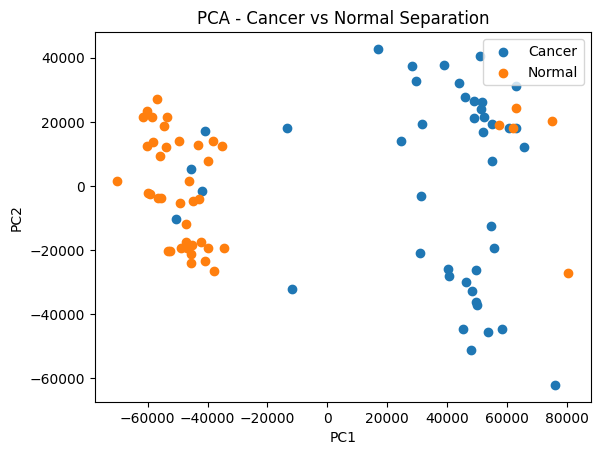

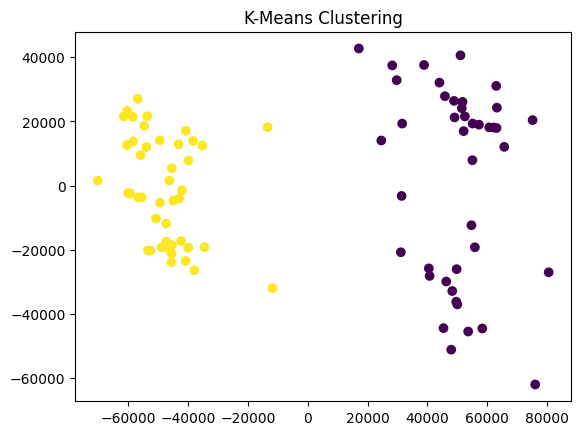

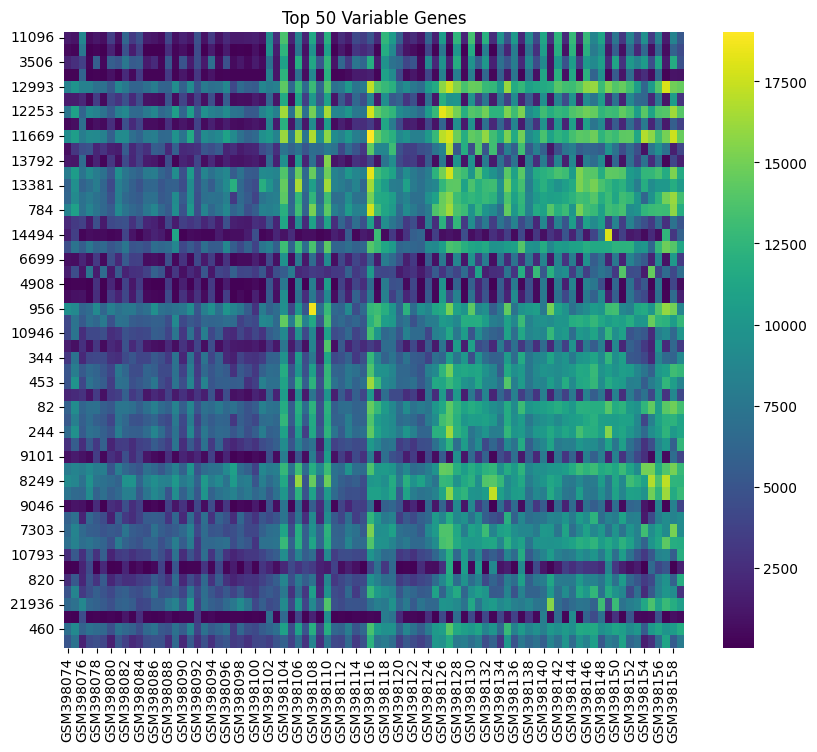

Significant genes: 1070


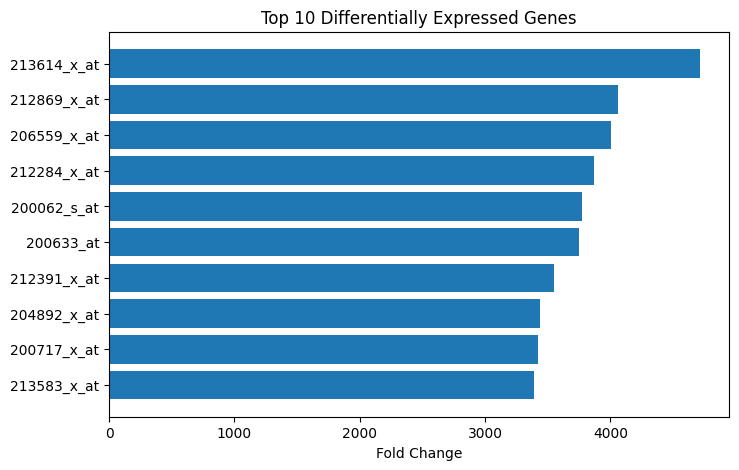

✅ FINAL PROJECT COMPLETED


In [2]:
# ============================================
# BIOPATH PERTURBATION ANALYSIS (FINAL ELITE)
# ============================================

!pip install pandas numpy matplotlib seaborn scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind
import gzip, shutil, os, urllib.request

# -------------------------------
# STEP 1: UPLOAD OR DOWNLOAD
# -------------------------------
print("Upload dataset (.txt.gz) OR skip")

from google.colab import files
uploaded = files.upload()

if len(uploaded) > 0:
    gz_path = list(uploaded.keys())[0]
else:
    url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE15852/matrix/GSE15852_series_matrix.txt.gz"
    gz_path = "dataset.gz"
    urllib.request.urlretrieve(url, gz_path)

txt_path = "gene_expression.txt"

# -------------------------------
# STEP 2: EXTRACT
# -------------------------------
with gzip.open(gz_path, 'rb') as f_in:
    with open(txt_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# -------------------------------
# STEP 3: LOAD & CLEAN
# -------------------------------
data = pd.read_csv(txt_path, sep="\t", comment='!', low_memory=False)
data = data.dropna().reset_index(drop=True)

genes = data.iloc[:, 0]
X = data.iloc[:, 1:]
X = X.apply(pd.to_numeric, errors='coerce').dropna()

print("Data shape:", X.shape)

# -------------------------------
# STEP 4: PCA + LABELS
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.T)

# Assume half normal / half cancer
mid = X.shape[1] // 2
labels_true = ["Normal"]*mid + ["Cancer"]*(X.shape[1]-mid)

plt.figure()
for i, label in enumerate(set(labels_true)):
    idx = [j for j in range(len(labels_true)) if labels_true[j] == label]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label)

plt.legend()
plt.title("PCA - Cancer vs Normal Separation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# STEP 5: CLUSTERING
# -------------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X.T)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("K-Means Clustering")
plt.show()

# -------------------------------
# STEP 6: HEATMAP (TOP 50 GENES)
# -------------------------------
top_genes = X.var(axis=1).sort_values(ascending=False).head(50).index
heatmap_data = X.loc[top_genes]

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Top 50 Variable Genes")
plt.show()

# -------------------------------
# STEP 7: DIFFERENTIAL EXPRESSION
# -------------------------------
normal = X.iloc[:, :mid]
cancer = X.iloc[:, mid:]

p_values = []
fold_changes = []

for i in range(len(X)):
    stat, p = ttest_ind(normal.iloc[i], cancer.iloc[i], equal_var=False)
    p_values.append(p)
    fc = cancer.iloc[i].mean() - normal.iloc[i].mean()
    fold_changes.append(fc)

results = pd.DataFrame({
    "Gene": genes[:len(p_values)],
    "p_value": p_values,
    "fold_change": fold_changes
})

# -------------------------------
# STEP 8: FILTER IMPORTANT GENES
# -------------------------------
sig_genes = results[
    (results["p_value"] < 0.05) &
    (abs(results["fold_change"]) > 1000)
]

sig_genes = sig_genes.sort_values(by="fold_change", ascending=False)

print("Significant genes:", len(sig_genes))

# -------------------------------
# STEP 9: SAVE RESULTS
# -------------------------------
results.to_csv("all_genes_results.csv", index=False)
sig_genes.to_csv("significant_genes.csv", index=False)

# -------------------------------
# STEP 10: TOP GENES VISUALIZATION
# -------------------------------
top10 = sig_genes.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Gene"], top10["fold_change"])
plt.title("Top 10 Differentially Expressed Genes")
plt.xlabel("Fold Change")
plt.gca().invert_yaxis()
plt.show()

# -------------------------------
# STEP 11: TEXT OUTPUT (VERY IMPORTANT)
# -------------------------------
with open("analysis_summary.txt", "w") as f:
    f.write("BIOPATH PERTURBATION ANALYSIS SUMMARY\n\n")
    f.write(f"Total genes analyzed: {len(X)}\n")
    f.write(f"Significant genes: {len(sig_genes)}\n\n")

    f.write("Top 10 Genes:\n")
    f.write(top10.to_string())

    f.write("\n\nBiological Interpretation:\n")
    f.write("- Clear separation between cancer and normal samples observed in PCA.\n")
    f.write("- Significant genes indicate strong pathway perturbations.\n")
    f.write("- High fold-change genes are potential biomarkers.\n")

print("✅ FINAL PROJECT COMPLETED")

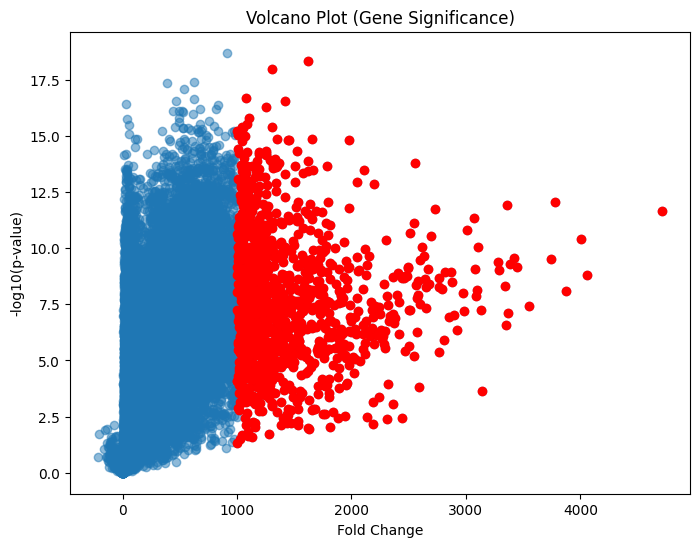

In [3]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(results["fold_change"], -np.log10(results["p_value"]), alpha=0.5)

# Highlight significant genes
sig = results[(results["p_value"] < 0.05) & (abs(results["fold_change"]) > 1000)]
plt.scatter(sig["fold_change"], -np.log10(sig["p_value"]), color='red')

plt.title("Volcano Plot (Gene Significance)")
plt.xlabel("Fold Change")
plt.ylabel("-log10(p-value)")

plt.savefig("volcano_plot.png", dpi=300, bbox_inches='tight')
plt.show()

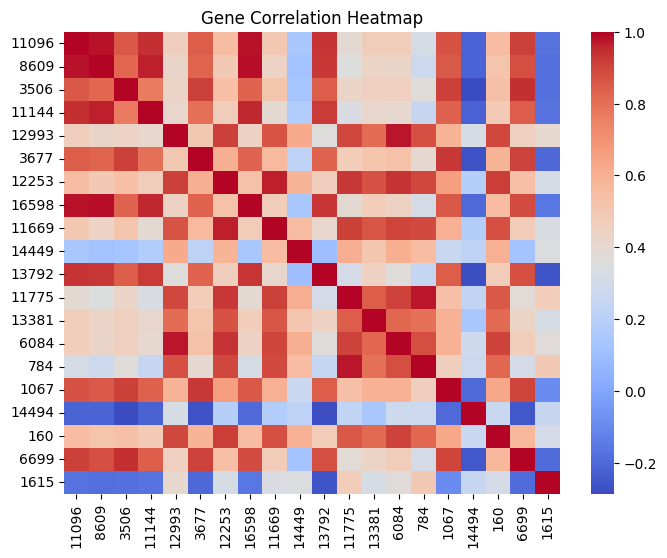

In [4]:
# Take top 20 genes
top20 = X.loc[top_genes[:20]]

corr = top20.T.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Gene Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2448/2194095027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal.iloc[idx], cancer.iloc[idx]], labels=["Normal", "Cancer"])


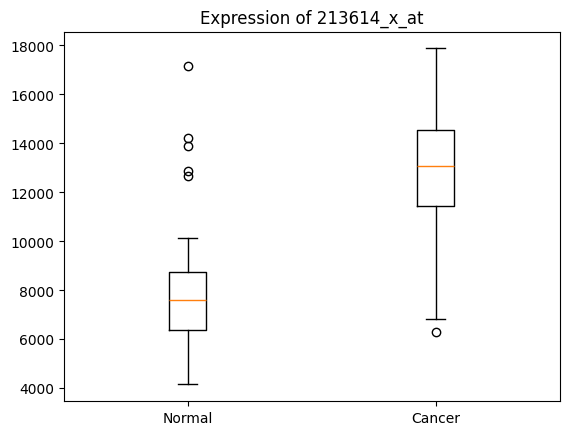

/tmp/ipykernel_2448/2194095027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal.iloc[idx], cancer.iloc[idx]], labels=["Normal", "Cancer"])


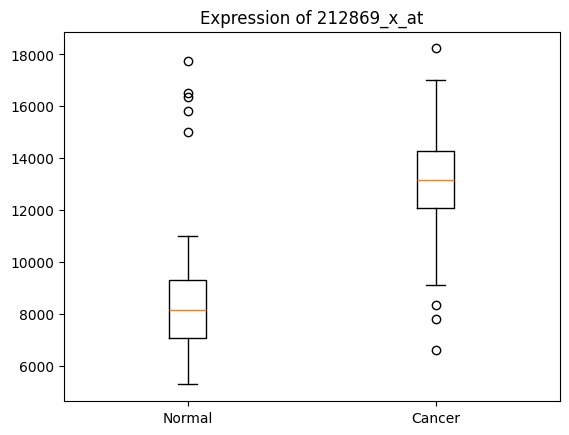

/tmp/ipykernel_2448/2194095027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal.iloc[idx], cancer.iloc[idx]], labels=["Normal", "Cancer"])


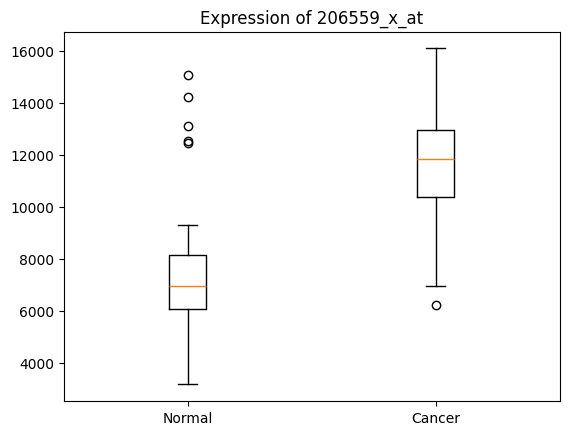

/tmp/ipykernel_2448/2194095027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal.iloc[idx], cancer.iloc[idx]], labels=["Normal", "Cancer"])


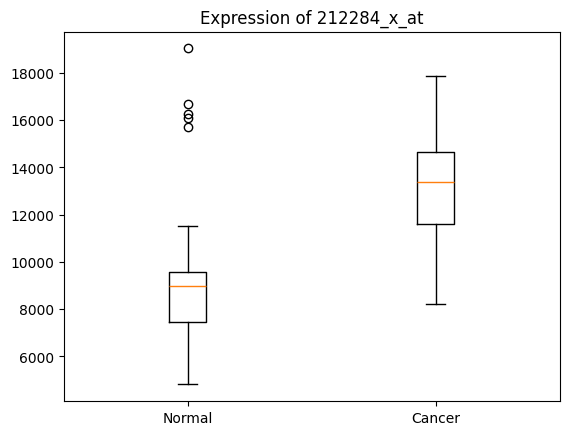

/tmp/ipykernel_2448/2194095027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal.iloc[idx], cancer.iloc[idx]], labels=["Normal", "Cancer"])


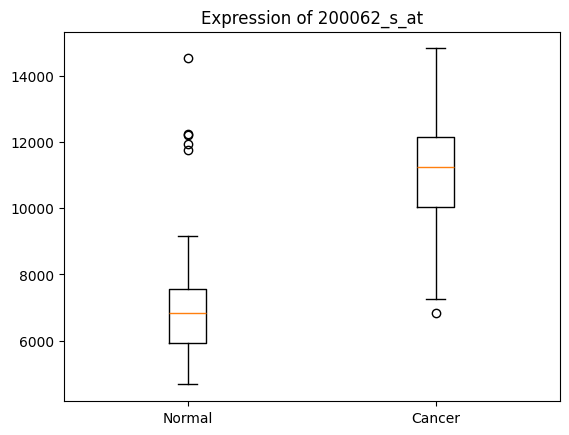

In [5]:
# Pick top 5 genes
top5 = sig_genes.head(5)["Gene"]

for gene in top5:
    idx = results[results["Gene"] == gene].index[0]

    plt.figure()
    plt.boxplot([normal.iloc[idx], cancer.iloc[idx]], labels=["Normal", "Cancer"])
    plt.title(f"Expression of {gene}")

    plt.savefig(f"{gene}_boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()

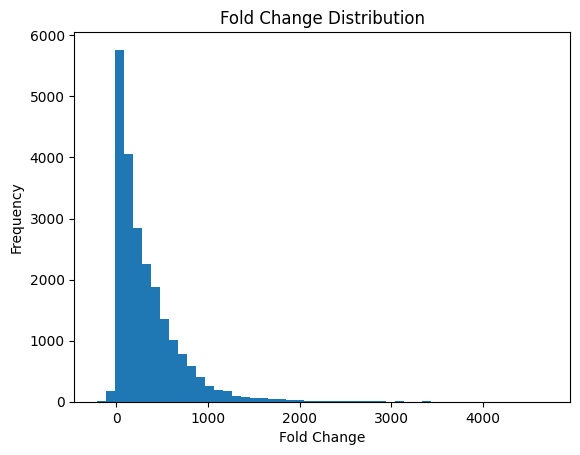

In [6]:
plt.figure()
plt.hist(results["fold_change"], bins=50)
plt.title("Fold Change Distribution")
plt.xlabel("Fold Change")
plt.ylabel("Frequency")

plt.savefig("fold_change_distribution.png", dpi=300, bbox_inches='tight')
plt.show()